In [10]:
from transformers import *

c:\Users\aa133\miniconda3\envs\llm-project\lib\site-packages\transformers\deepspeed.py:24: FutureWarning: transformers.deepspeed module is deprecated and will be removed in a future version. Please import deepspeed modules directly from transformers.integrations
  warnings.warn(


In [ ]:
import gradio as gr
from transformers import pipeline

# 1. 规范导入：只明确导入 pipeline
# 加载大众点评中文情感微调模型
classifier = pipeline("text-classification", model="uer/roberta-base-finetuned-dianping-chinese")

# 2. 显式定义处理函数：把 pipeline 的原始输出转换为 Gradio Label 需要的格式
def predict_sentiment(text):
    result = classifier(text)[0]  # pipeline 默认返回列表，取出第一个字典
    return {result['label']: result['score']}

# 3. 构建现代 Gradio 界面，自定义中文组件
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(label="请输入待分类的文本", placeholder="例如：这家餐厅味道真不错..."),
    outputs=gr.Label(label="情感倾向预测结果"),
    title="大众点评文本分类服务"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Using existing dataset file at: .gradio\flagged\dataset1.csv


In [1]:
# Pipeline's type of task
from transformers.pipelines import get_supported_tasks

# 获取并打印所有支持的任务列表
tasks = get_supported_tasks()
for task in tasks:
    print(task)

audio-classification
automatic-speech-recognition
depth-estimation
document-question-answering
feature-extraction
fill-mask
image-classification
image-feature-extraction
image-segmentation
image-to-image
image-to-text
mask-generation
ner
object-detection
question-answering
sentiment-analysis
summarization
table-question-answering
text-classification
text-generation
text-to-audio
text-to-speech
text2text-generation
token-classification
translation
video-classification
visual-question-answering
vqa
zero-shot-audio-classification
zero-shot-classification
zero-shot-image-classification
zero-shot-object-detection


In [1]:
# Pipeline创建 指定任务类型
from transformers import pipeline
pipe = pipeline("text-classification")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\aa133\miniconda3\envs\llm-project\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aa133\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is n

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [4]:
# 使用
pipe("Very Good")

[{'label': 'POSITIVE', 'score': 0.9998520612716675}]

In [ ]:
# 再指定具体的模型 可以去huggingface搜索文本分类模型
from transformers import pipeline
pipe = pipeline("text-classification",model="hoodiexxx/Bert_Chinese_Text_Classification_Model")


In [ ]:
# 预先加载模型 在创建pipeline
...
# 注意要标识分词器

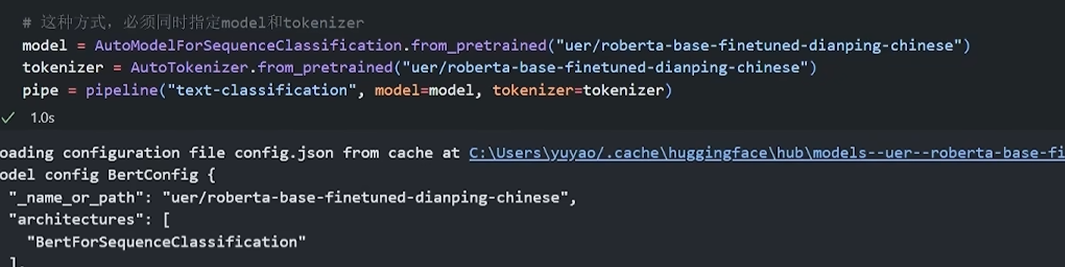

In [5]:
pipe.model.device

device(type='cpu')

In [ ]:
# 使用GPU推理  本设备无CUDA
pipe = pipeline("text-classification",device=0)


In [5]:
# 确定Pipeline参数
from transformers import pipeline 
qa_pipe = pipeline("question-answering")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 626af31 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


In [6]:
qa_pipe
# 发现其后缀：QuestionAnsweringPipeline

In [ ]:
QuestionAnsweringPipeline
# ctrl进去研究 其中的call方法就是我们可以输入的参数

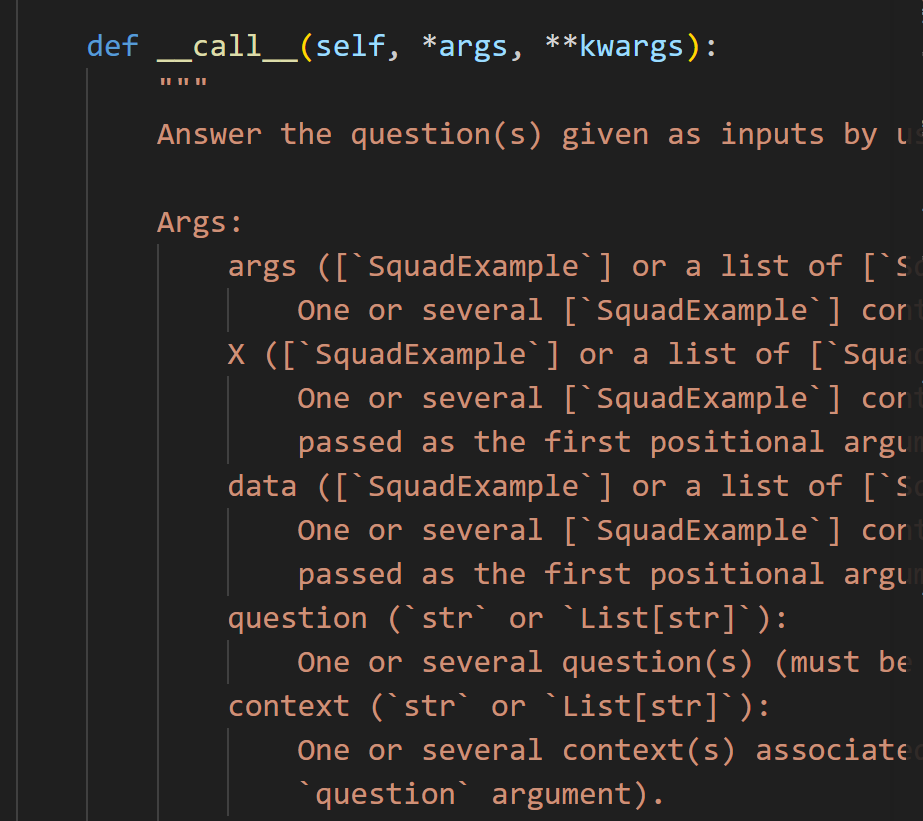

In [12]:
qa_pipe(question="What is the capital of France?",context= "France's capital is Paris",max_answer_len=1)


{'score': 0.9836698770523071, 'start': 20, 'end': 25, 'answer': 'Paris'}

In [11]:
qa_pipe(question="What is the capital of France?",context= "France's capital is Peiking",max_answer_len=1)

{'score': 0.0005583810270763934, 'start': 20, 'end': 27, 'answer': 'Peiking'}

In [ ]:
# 其他Pipeline示例 (图像识别 略)
checkpoint = "google/owlvit-base-patch32"
detector = pipeline(model=checkpoint, task="zero-shot-object-detection")